# FIRMS quickstart — recent active fires

Fetch recent **active-fire detections** (MODIS / VIIRS) from [NASA FIRMS](https://firms.modaps.eosdis.nasa.gov/) through the `earthlens` FIRMS backend, and plot the fire pixels coloured by fire radiative power (FRP).

FIRMS is a `vector` backend: `download()` returns a pyramids `FeatureCollection` (a `geopandas.GeoDataFrame`, CRS `EPSG:4326`), one row per fire pixel.

## Setup

Pull in the imports up front: `EarthLens` is the unified entry point and `matplotlib.pyplot` is used for the final scatter. We also prepare an output directory — FIRMS is a file-writing-plus-in-memory `vector` backend, so `download()` writes the detections to `firms_output/` and returns them as a `GeoDataFrame`.

In [1]:
import datetime as dt
import os
import pathlib
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display

from earthlens.core import EarthLens

# Off the system drive; override with EARTHLENS_CACHE.
OUT_DIR = Path(os.environ.get('EARTHLENS_CACHE', 'D:/earthlens-cache')) / 'firms'
OUT_DIR.mkdir(parents=True, exist_ok=True)

### Credentials

FIRMS needs a free `MAP_KEY` (https://firms.modaps.eosdis.nasa.gov/api/map_key/). Set `FIRMS_MAP_KEY` in your environment; the live cells below skip cleanly when it is absent, so the notebook never fails offline.

In [2]:
HAS_KEY = bool(os.environ.get('FIRMS_MAP_KEY'))
print('FIRMS_MAP_KEY set:', HAS_KEY)

FIRMS_MAP_KEY set: True


## Query

`variables` is a list of FIRMS **sensor codes** (not data variables). We use the 375 m VIIRS S-NPP near-real-time sensor over Southern California for a recent 7-day window. FIRMS caps requests at 10 days / one sensor, but the backend chunks longer windows transparently.

### Date window

FIRMS near-real-time retains only the most recent ~2 months, so we anchor the window to a recent 7-day span ending today.

In [3]:
TODAY = dt.date.today()
START = (TODAY - dt.timedelta(days=7)).strftime('%Y-%m-%d')
END = TODAY.strftime('%Y-%m-%d')

### Build the request and download

We build the `EarthLens` request first — source, sensor (`variables`), date window, bounding box, and output path — then call `download()` as a separate step. The whole thing stays inside a guard so the notebook skips cleanly when no `MAP_KEY` is set or the live query fails. The result is written to `firms_output/` and returned in memory.

In [4]:
fires = None
if HAS_KEY:
    try:
        request = EarthLens(
            data_source='firms',
            variables=['VIIRS_SNPP_NRT'],
            start=START,
            end=END,
            aoi=[-119.0, 33.0, -117.0, 35.0],
            path=OUT_DIR,
        )
        fires = request.download(progress_bar=False)
        print('detections:', len(fires))
    except Exception as exc:  # keep the notebook safe offline
        print('skipped live query:', exc)

2026-09-08 23:40:53.522 | INFO     | earthlens.firms.backend:_search:335 - FIRMS request: 1 sensor(s) x 2 chunk(s) = 2 CSV GET(s)


2026-09-08 23:40:55.681 | INFO     | earthlens.firms.backend:download:583 - FIRMS download summary: 137 detection(s) written to D:\earthlens-cache\firms\firms_VIIRS_SNPP_NRT_20260901_20260908.gpkg


detections: 137


## Inspect the detections

Every row is one fire pixel with a normalised `confidence_pct` and `frp` (MW).

In [5]:
if fires is not None and len(fires):
    cols = [
        'acq_datetime',
        'sensor',
        'confidence',
        'confidence_pct',
        'brightness_k',
        'frp',
        'daynight',
        'geometry',
    ]
    display(fires[cols].head())
    print('CRS:', fires.crs)

,acq_datetime,sensor,confidence,confidence_pct,brightness_k,frp,daynight,geometry
0,2026-09-01 10:09:00+00:00,VIIRS_SNPP_NRT,n,60.0,305.74,0.77,N,POINT (-118.23653 33.77805)
1,2026-09-01 10:09:00+00:00,VIIRS_SNPP_NRT,n,60.0,299.73,0.86,N,POINT (-117.47224 33.7921)
2,2026-09-01 10:09:00+00:00,VIIRS_SNPP_NRT,n,60.0,303.79,0.81,N,POINT (-117.4776 33.79315)
3,2026-09-01 10:09:00+00:00,VIIRS_SNPP_NRT,n,60.0,303.57,0.94,N,POINT (-118.22765 33.81038)
4,2026-09-01 10:09:00+00:00,VIIRS_SNPP_NRT,n,60.0,306.30,2.01,N,POINT (-118.23267 33.81134)


CRS: EPSG:4326


## Plot the fire pixels coloured by FRP

Plotting the `GeoDataFrame` directly with `column='frp'` colours each detection by its fire radiative power, so the most intense pixels stand out.

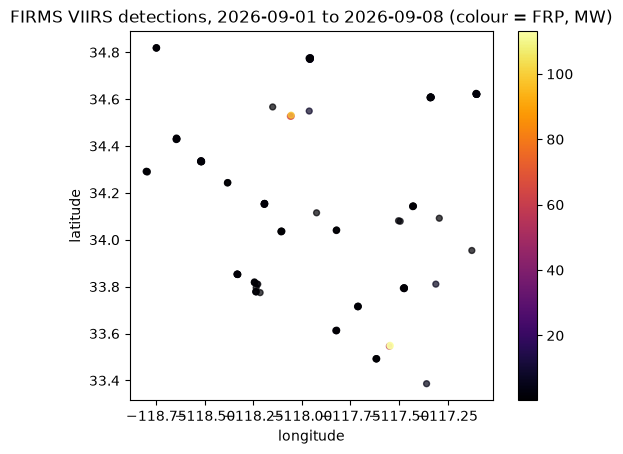

In [6]:
if fires is not None and len(fires):
    ax = fires.plot(column='frp', cmap='inferno', markersize=18, alpha=0.7, legend=True)
    ax.set_title(f'FIRMS VIIRS detections, {START} to {END} (colour = FRP, MW)')
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    plt.show()

## Inspecting individual detections — Digital-Earth's interactive tier

The scatter above answers "where were the fires"; it cannot answer "what is *that* one". Every detection
carries a brightness, a confidence, an FRP and an acquisition time, and a static PNG shows none of them.

`digitalearth.interactive.InteractiveMap` renders the same points through HoloViz over an XYZ basemap, so
the map pans and zooms and `hover` puts each detection's own attributes under the cursor. The `rasterize`
threshold means this keeps working when a query returns hundreds of thousands of detections instead of a
few hundred — past the threshold the points are aggregated server-side into an image rather than shipped to
the browser individually.

interactive map : D:\earthlens-cache\firms\firms_detections.html   <- open this one to pan, zoom and hover
static preview  : D:\earthlens-cache\firms\firms_detections.png


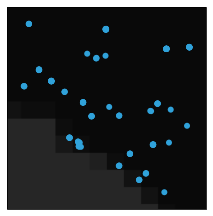

In [7]:
if fires is not None and len(fires):
    import holoviews as hv

    from digitalearth.interactive import InteractiveMap

    fire_map = (
        InteractiveMap(width=860, height=560)
        .tiles('CartoDark')
        .points(fires, value_column='frp', cmap='inferno', size=7)
        .hover(tooltips=[
            ('acquired', '@acq_datetime{%F %H:%M}'),
            ('FRP (MW)', '@frp{0.0}'),
            ('brightness (K)', '@brightness_k{0.0}'),
            ('confidence', '@confidence'),
            ('day/night', '@daynight'),
        ], formatters={'@acq_datetime': 'datetime'})
        .colorbar()
    )

    # The live map is a Bokeh document: it needs a running kernel, and notebook
    # viewers strip scripts out of saved HTML output, so it cannot be embedded here.
    # Write it as a standalone file for the pan/zoom/hover version...
    fire_html = fire_map.save(str(OUT_DIR / 'firms_detections.html'))
    # ...and render the same overlay through HoloViews' matplotlib backend for a
    # still that does survive in the notebook. No browser needed, unlike Bokeh's
    # own PNG export, which wants selenium.
    fire_png = str(OUT_DIR / 'firms_detections.png')
    hv.save(fire_map.render(), fire_png, backend='matplotlib', fmt='png')

    print(f'interactive map : {fire_html}   <- open this one to pan, zoom and hover')
    print(f'static preview  : {fire_png}')
    display(Image(filename=fire_png))